# GPR Cross-Validation and Model Quality Metrics

This notebook cross-validates the **actual BayBE Gaussian Process Regression (GPR) surrogate model** (botorch `SingleTaskGP`) that underlies the SHAP explanations used in the publication. Rather than fitting separate sklearn models, we use BayBE's own `campaign.get_surrogate()` API to train and evaluate the identical model architecture.

## Approach

For each of the 6 individual campaign datasets:
1. Load the pre-processed campaign data (features + calibrated deposition rate + Ipk)
2. Reconstruct a BayBE Campaign with the same parameter bounds and feature set
3. Perform k-fold cross-validation using `model.fit()` / `model.posterior()` on the BayBE surrogate
4. Report RÂ², RMSE, MAE, and extract kernel hyperparameters (lengthscales, outputscale, noise)

**Note on combined datasets:** The combined (Al_combined, Ti_combined, global) SHAP objects were created by merging data from multiple campaigns with different search spaces. Cross-validating these would require reconstructing the exact merge logic, which is outside the scope of this notebook. The individual dataset validations already demonstrate the surrogate model quality.

In [46]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import baybe
import InitializeCampaign as ic

## Dataset Reconstruction

Each dataset folder contains a pre-processed `df_campaign_*.json` file with the measured features (including Ipk) and the calibrated deposition rate (y1). We load these directly and create BayBE Campaigns with the same parameter set used for the SHAP analysis:

- `Ipk (A)` â€” Peak current density
- `PW (us)` â€” Negative pulse width
- `PRR (Hz)` â€” Pulse repetition rate (computed from duty cycle for some datasets)
- `pos. Delay (us)` â€” Positive pulse delay
- `pos. PW (us)` â€” Positive pulse width
- `pos. Setpoint (V)` â€” Positive pulse voltage

In [47]:
base_dir = Path.cwd()
HEAD_PATH = base_dir / "Bipolar Datasets - Al and Ti - low and high PW" / "Datasets Used for Publication"

# Registry of datasets and their pre-processed data files
dataset_registry = {
    'Al - 120 W  - short PW': 'df_campaign_Al_shortPW.json',
    'Al - 200 W - high PW': 'df_campaign_Al_highPW.json',
    'Al - 250 W - duty cycle series': 'df_campaign_Al_lowDuty.json',
    'Ti - 120 W - short PW': 'df_campaign_Ti_lowPW.json',
    'Ti - 200 W - high PW': 'df_campaign_Ti_highPW.json',
    'Ti 250 W low duty cycle': 'df_campaign_Ti_lowDuty.json',
}

In [48]:
def reconstruct_campaign(folder_path, df_file):
    """
    Load pre-processed campaign data and create a BayBE Campaign.
    
    Returns:
        campaign: BayBE Campaign object with measurements added
        df_clean: Clean DataFrame with features + target
    """
    df = pd.read_json(folder_path / df_file)
    
    # Compute PRR from duty cycle if not present
    if 'PRR (Hz)' not in df.columns:
        df['PRR (Hz)'] = df['Duty Cycle (ratio)'] / (df['PW (us)'] * 1E-6)
    
    # Define the parameter set matching the SHAP analysis
    params = ['Ipk (A)', 'PW (us)', 'PRR (Hz)', 'pos. Delay (us)', 'pos. PW (us)', 'pos. Setpoint (V)']
    df_clean = df[params + ['y1']].copy()
    
    # Create campaign with data-derived bounds
    lower_bounds = [df_clean[p].min() for p in params]
    upper_bounds = [df_clean[p].max() for p in params]
    campaign = ic.init_campaign(lower_bounds, upper_bounds, params)
    campaign.add_measurements(df_clean)
    
    return campaign, df_clean

In [49]:
# Reconstruct all campaigns
campaigns = {}
clean_data = {}

for name, df_file in dataset_registry.items():
    folder_path = HEAD_PATH / name
    campaign, df_clean = reconstruct_campaign(folder_path, df_file)
    campaigns[name] = campaign
    clean_data[name] = df_clean
    print(f"{name}: {len(df_clean)} samples, y1 range = [{df_clean['y1'].min():.3f}, {df_clean['y1'].max():.3f}]")

c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Al - 120 W  - short PW: 601 samples, y1 range = [0.078, 1.577]


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Al - 200 W - high PW: 651 samples, y1 range = [1.578, 3.289]
Al - 250 W - duty cycle series: 401 samples, y1 range = [0.588, 4.046]


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(
c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Ti - 120 W - short PW: 495 samples, y1 range = [0.103, 1.106]


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


Ti - 200 W - high PW: 601 samples, y1 range = [0.861, 1.479]
Ti 250 W low duty cycle: 401 samples, y1 range = [0.445, 2.223]


c:\Users\rona\AppData\Local\anaconda3\envs\bo_sota\Lib\site-packages\baybe\targets\numerical.py:146: DeprecationWarning: Creating numerical targets by specifying MAX/MIN/MATCH modes has been deprecated. For now, you do not need to change your code as we automatically converted your target to the new format. However, this functionality will be removed in a future version, so please familiarize yourself with the new interface.
  warnings.warn(


## Cross-Validation with BayBE GPR Surrogate

For each fold, we:
1. Get a fresh surrogate model via `campaign.get_surrogate()`
2. Train it on the training fold using `model.fit(searchspace, objective, df_train)`
3. Predict on the test fold using `model.posterior(df_test_features)`
4. Compare `posterior.mean` (model predictions in the original target scale) against actual y1 values

The BayBE GPR surrogate is a botorch `SingleTaskGP` with:
- Matern 5/2 kernel with automatic relevance determination (ARD)
- Internal input normalization (`Normalize` transform)
- Internal output standardization (`Standardize` transform)
- Hyperparameters optimized via marginal log-likelihood

In [50]:
def cross_validate_baybe_gpr(campaign, df_clean, n_splits=5):
    """
    K-fold cross-validation using BayBE's GPR surrogate.
    
    Returns:
        dict with per-fold and aggregated metrics (train + test), plus pooled predictions.
    """
    params = [p.name for p in campaign.parameters]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    y_true_all, y_pred_all = [], []
    fold_metrics = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(df_clean)):
        df_train = df_clean.iloc[train_idx].reset_index(drop=True)
        df_test = df_clean.iloc[test_idx].reset_index(drop=True)
        
        # Get a fresh surrogate and fit on training fold
        model = campaign.get_surrogate()
        model.fit(campaign.searchspace, campaign.objective, df_train)
        
        with torch.no_grad():
            # Test predictions
            posterior_test = model.posterior(df_test[params])
            y_pred_test = posterior_test.mean.detach().numpy().flatten()
            
            # Train predictions (to measure train/test gap)
            posterior_train = model.posterior(df_train[params])
            y_pred_train = posterior_train.mean.detach().numpy().flatten()
        
        y_true_test = df_test['y1'].values
        y_true_train = df_train['y1'].values
        
        y_true_all.extend(y_true_test)
        y_pred_all.extend(y_pred_test)
        
        fold_metrics.append({
            'R2_test': r2_score(y_true_test, y_pred_test),
            'R2_train': r2_score(y_true_train, y_pred_train),
            'RMSE': np.sqrt(mean_squared_error(y_true_test, y_pred_test)),
            'MAE': mean_absolute_error(y_true_test, y_pred_test),
        })
    
    r2_tests = [m['R2_test'] for m in fold_metrics]
    r2_trains = [m['R2_train'] for m in fold_metrics]
    
    return {
        'fold_metrics': fold_metrics,
        'y_true_all': np.array(y_true_all),
        'y_pred_all': np.array(y_pred_all),
        'R2_test_mean': np.mean(r2_tests),
        'R2_test_std': np.std(r2_tests),
        'R2_train_mean': np.mean(r2_trains),
        'R2_train_std': np.std(r2_trains),
        'R2_gap_mean': np.mean([t - e for t, e in zip(r2_trains, r2_tests)]),
        'RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'MAE_std': np.std([m['MAE'] for m in fold_metrics]),
    }

In [51]:
# Run cross-validation for all datasets
results = {}

for name in dataset_registry:
    campaign = campaigns[name]
    df_clean = clean_data[name]
    
    n_splits = 5 if len(df_clean) >= 10 else 3
    
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"Samples: {len(df_clean)}, Features: {len(campaign.parameters)}")
    
    result = cross_validate_baybe_gpr(campaign, df_clean, n_splits=n_splits)
    results[name] = result
    
    print(f"Train R² = {result['R2_train_mean']:.4f} ± {result['R2_train_std']:.4f}")
    print(f"Test  R² = {result['R2_test_mean']:.4f} ± {result['R2_test_std']:.4f}")
    print(f"R² gap (train - test) = {result['R2_gap_mean']:.4f}")
    print(f"RMSE = {result['RMSE_mean']:.4f} ± {result['RMSE_std']:.4f}")
    print(f"MAE  = {result['MAE_mean']:.4f} ± {result['MAE_std']:.4f}")


Dataset: Al - 120 W  - short PW
Samples: 601, Features: 6
Train R² = 0.8720 ± 0.0057
Test  R² = 0.8214 ± 0.0393
R² gap (train - test) = 0.0506
RMSE = 0.1058 ± 0.0035
MAE  = 0.0867 ± 0.0034

Dataset: Al - 200 W - high PW
Samples: 651, Features: 6
Train R² = 0.9263 ± 0.0424
Test  R² = 0.7887 ± 0.1484
R² gap (train - test) = 0.1376
RMSE = 0.0880 ± 0.0363
MAE  = 0.0494 ± 0.0070

Dataset: Al - 250 W - duty cycle series
Samples: 401, Features: 6
Train R² = 0.7836 ± 0.0102
Test  R² = 0.7030 ± 0.0472
R² gap (train - test) = 0.0806
RMSE = 0.2956 ± 0.0407
MAE  = 0.2184 ± 0.0125

Dataset: Ti - 120 W - short PW
Samples: 495, Features: 6
Train R² = 0.8469 ± 0.0164
Test  R² = 0.7402 ± 0.0634
R² gap (train - test) = 0.1067
RMSE = 0.0841 ± 0.0057
MAE  = 0.0674 ± 0.0057

Dataset: Ti - 200 W - high PW
Samples: 601, Features: 6
Train R² = 0.6685 ± 0.0122
Test  R² = 0.6106 ± 0.0582
R² gap (train - test) = 0.0579
RMSE = 0.0704 ± 0.0046
MAE  = 0.0587 ± 0.0044

Dataset: Ti 250 W low duty cycle
Samples: 401,

## Summary Table

In [52]:
summary_data = []
for name, result in results.items():
    summary_data.append({
        'Dataset': name,
        'N': len(clean_data[name]),
        'Train R²': f"{result['R2_train_mean']:.3f} ± {result['R2_train_std']:.3f}",
        'Test R²': f"{result['R2_test_mean']:.3f} ± {result['R2_test_std']:.3f}",
        'R² Gap': f"{result['R2_gap_mean']:.3f}",
        'RMSE': f"{result['RMSE_mean']:.4f} ± {result['RMSE_std']:.4f}",
        'MAE': f"{result['MAE_mean']:.4f} ± {result['MAE_std']:.4f}",
    })

df_summary = pd.DataFrame(summary_data)
df_summary

,Dataset,N,Train R²,Test R²,R² Gap,RMSE,MAE
0,Al - 120 W - short PW,601,0.872 ± 0.006,0.821 ± 0.039,0.051,0.1058 ± 0.0035,0.0867 ± 0.0034
1,Al - 200 W - high PW,651,0.926 ± 0.042,0.789 ± 0.148,0.138,0.0880 ± 0.0363,0.0494 ± 0.0070
2,Al - 250 W - duty cycle series,401,0.784 ± 0.010,0.703 ± 0.047,0.081,0.2956 ± 0.0407,0.2184 ± 0.0125
3,Ti - 120 W - short PW,495,0.847 ± 0.016,0.740 ± 0.063,0.107,0.0841 ± 0.0057,0.0674 ± 0.0057
4,Ti - 200 W - high PW,601,0.669 ± 0.012,0.611 ± 0.058,0.058,0.0704 ± 0.0046,0.0587 ± 0.0044
5,Ti 250 W low duty cycle,401,0.741 ± 0.019,0.648 ± 0.048,0.093,0.1881 ± 0.0293,0.1368 ± 0.0149


## Parity Plots (Cross-Validated Predictions vs. Actual)

Predictions are pooled across all k folds â€” each point was predicted when it was in the held-out test set.

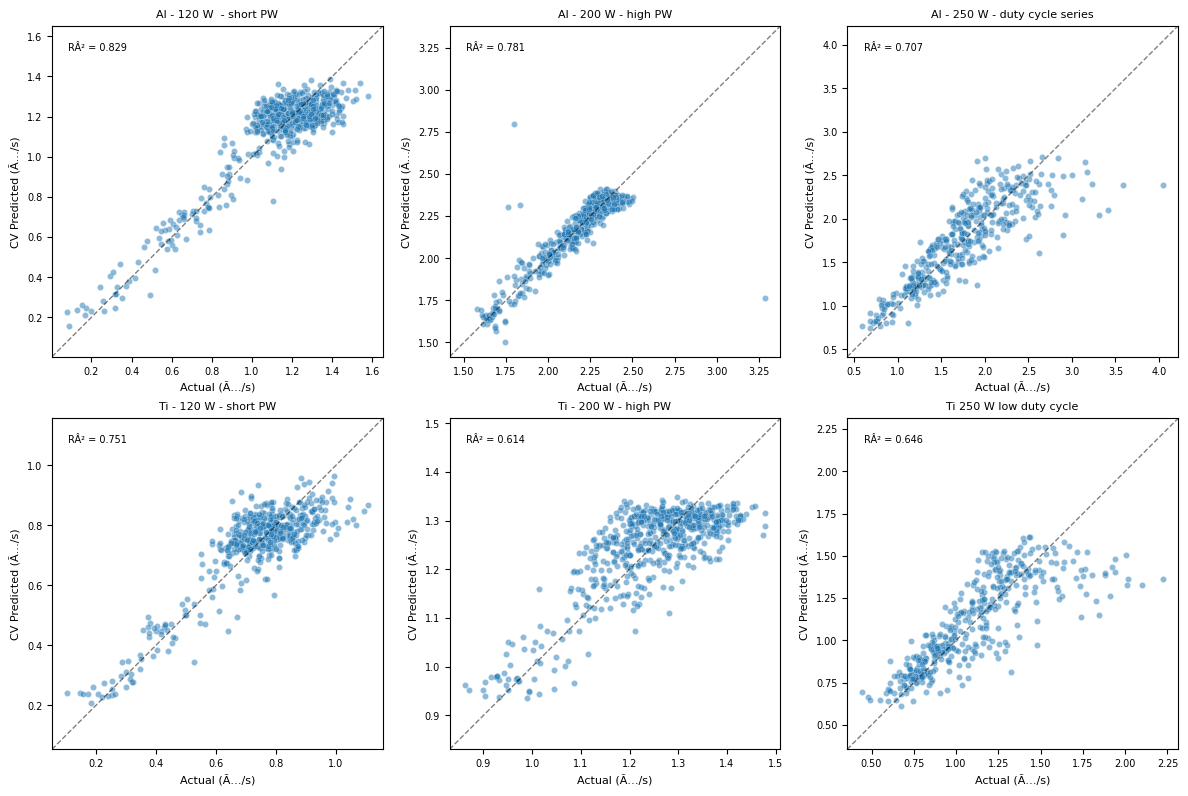

In [53]:
n_datasets = len(results)
n_cols = 3
n_rows = int(np.ceil(n_datasets / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    y_true = result['y_true_all']
    y_pred = result['y_pred_all']
    
    ax.scatter(y_true, y_pred, s=20, alpha=0.5, edgecolor='white', linewidth=0.3)
    
    # Parity line
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    margin = (lims[1] - lims[0]) * 0.05
    ax.plot([lims[0]-margin, lims[1]+margin], [lims[0]-margin, lims[1]+margin],
            'k--', linewidth=1, alpha=0.5)
    ax.set_xlim(lims[0]-margin, lims[1]+margin)
    ax.set_ylim(lims[0]-margin, lims[1]+margin)
    
    ax.set_xlabel('Actual (Ã…/s)', fontsize=8)
    ax.set_ylabel('CV Predicted (Ã…/s)', fontsize=8)
    ax.set_title(name, fontsize=8)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)
    
    r2 = r2_score(y_true, y_pred)
    ax.text(0.05, 0.95, f'RÂ² = {r2:.3f}', transform=ax.transAxes, fontsize=7, va='top')

for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Kernel Hyperparameters and Noise Estimates

These hyperparameters come from the surrogate fitted on the **full dataset** (all measurements), reflecting the final model used for SHAP explanation generation.

- **Lengthscales** (per feature, ARD): shorter lengthscale = model is more sensitive to that feature
- **Outputscale**: overall magnitude of the kernel
- **Noise**: estimated observation noise in the likelihood

In [54]:
def extract_botorch_gp(surrogate):
    """Extract the botorch SingleTaskGP from any BayBE surrogate type.
    
    Handles both GaussianProcessSurrogate (returns SingleTaskGP directly)
    and CompositeSurrogate (returns ModelListGP wrapping SingleTaskGP).
    """
    botorch_model = surrogate.to_botorch()
    # CompositeSurrogate.to_botorch() returns ModelListGP; unwrap it
    if hasattr(botorch_model, 'models'):
        return botorch_model.models[0]
    return botorch_model

print("Kernel Hyperparameters (Full-Data Fit)")
print("=" * 80)

for name in dataset_registry:
    campaign = campaigns[name]
    df_clean = clean_data[name]
    params = [p.name for p in campaign.parameters]
    
    # Fit on all data
    model = campaign.get_surrogate()
    model.fit(campaign.searchspace, campaign.objective, df_clean)
    
    print(f"\nDataset: {name}")
    
    botorch_model = extract_botorch_gp(model)
    lengthscales = botorch_model.covar_module.base_kernel.lengthscale.detach().numpy().flatten()
    outputscale = botorch_model.covar_module.outputscale.detach().item()
    noise_standardized = botorch_model.likelihood.noise.detach().item()
    
    # Rescale noise from standardized space to original Å/s units.
    # The botorch Standardize transform stores the training y std as .Ystd
    y_std = botorch_model.outcome_transform.means.item()  # not needed for noise
    y_scale = botorch_model.outcome_transform.stdvs.item()  # std of training y
    noise_original = np.sqrt(noise_standardized) * y_scale  # std dev in Å/s
    
    print(f"  Outputscale: {outputscale:.4f}")
    print(f"  Noise (standardized variance): {noise_standardized:.6f}")
    print(f"  Noise (Å/s, 1 std dev): {noise_original:.4f}")
    print(f"  Lengthscales (per feature):")
    for p, ls in zip(params, lengthscales):
        print(f"    {p}: {ls:.4f}")

Kernel Hyperparameters (Full-Data Fit)

Dataset: Al - 120 W  - short PW
  Outputscale: 1.6463
  Noise (standardized variance): 0.148401
  Noise (Å/s, 1 std dev): 0.0986
  Lengthscales (per feature):
    Ipk (A): 1.4248
    PRR (Hz): 1.7555
    PW (us): 0.2426
    pos. Delay (us): 5.7841
    pos. PW (us): 5.3962
    pos. Setpoint (V): 3.7642

Dataset: Al - 200 W - high PW
  Outputscale: 1.3565
  Noise (standardized variance): 0.126682
  Noise (Å/s, 1 std dev): 0.0725
  Lengthscales (per feature):
    Ipk (A): 0.6206
    PRR (Hz): 2.3621
    PW (us): 2.9851
    pos. Delay (us): 1.8512
    pos. PW (us): 2.7061
    pos. Setpoint (V): 1.9884

Dataset: Al - 250 W - duty cycle series
  Outputscale: 1.8825
  Noise (standardized variance): 0.252425
  Noise (Å/s, 1 std dev): 0.2775
  Lengthscales (per feature):
    Ipk (A): 1.2805
    PRR (Hz): 1.1940
    PW (us): 0.4126
    pos. Delay (us): 3.8101
    pos. PW (us): 3.7193
    pos. Setpoint (V): 2.8988

Dataset: Ti - 120 W - short PW
  Outputsca

## Residual Analysis

Distribution of residuals (actual - predicted) from the cross-validated predictions.

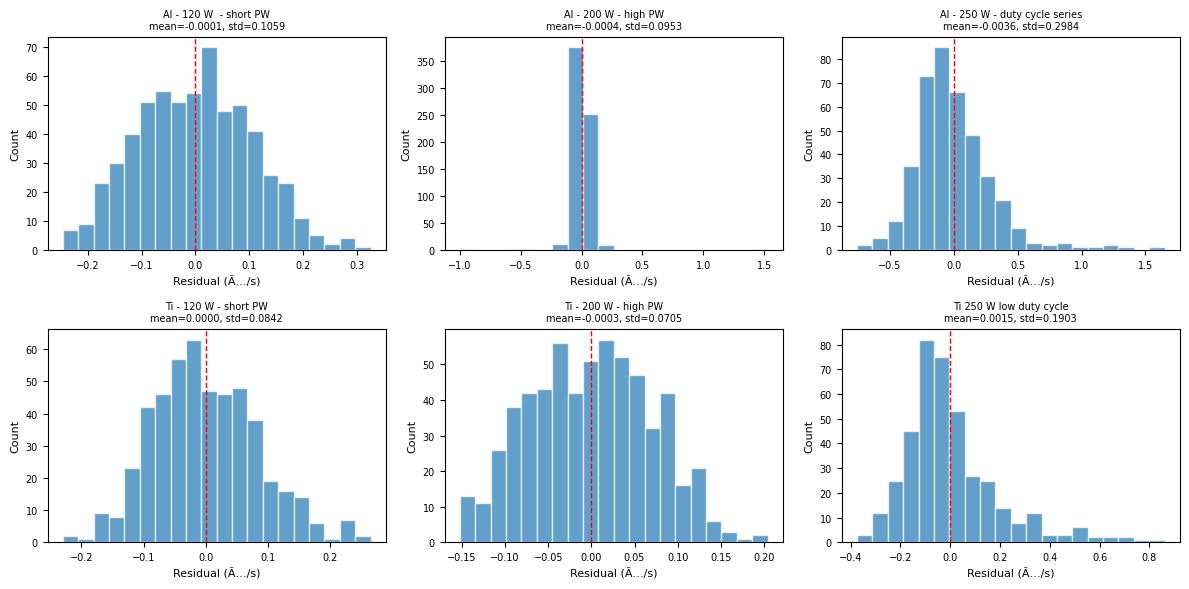

In [55]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    residuals = result['y_true_all'] - result['y_pred_all']
    
    ax.hist(residuals, bins=20, edgecolor='white', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Residual (Ã…/s)', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.set_title(f"{name}\nmean={np.mean(residuals):.4f}, std={np.std(residuals):.4f}", fontsize=7)
    ax.tick_params(labelsize=7)

for idx in range(n_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Notes

- The GPR model is re-trained from scratch on each fold, matching BayBE's internal procedure where `get_surrogate()` trains the model on demand from the provided measurements.
- Hyperparameter optimization (marginal log-likelihood) is non-deterministic, so slight variations across runs are expected.
- The combined dataset SHAP objects (`Al_combined_dataset_withPRR.pkl`, etc.) are not cross-validated here because they were created by merging data from multiple campaigns with different search space definitions. The individual campaign cross-validations demonstrate the quality of the same surrogate model architecture.